In [9]:
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import os

In [14]:
indir = os.path.expanduser('~/gdrive/Shared Drives/MACRO-Be/20A-357/')
outdir = os.path.expanduser('~/Desktop/Code/VLA-20A-357/')

source_list = ['10_CMa', '20_Vul', '25_Peg', '25_Vul', '120_Tau', 'eps_PsA', 'HR_2249', 'ome_Ori', 'ups_Cyg', 'zet_Crv']
diff_source_list = ['10CMa', '20Vul', '25Peg', '25Vul', '120Tau', 'epsPsA', 'HR2249', 'omeOri', 'upsCyg', 'zetCrv']

# Old Plots

Processing source 10_CMa
Processing source 20_Vul
Processing source 25_Peg
Processing source 25_Vul
Processing source 120_Tau
Processing source eps_PsA
Processing source HR_2249
Processing source ome_Ori
Processing source ups_Cyg
Processing source zet_Crv


/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2432300361.py:32: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(c_plots, leg_list, loc='upper left', bbox_to_anchor=(1, 1))


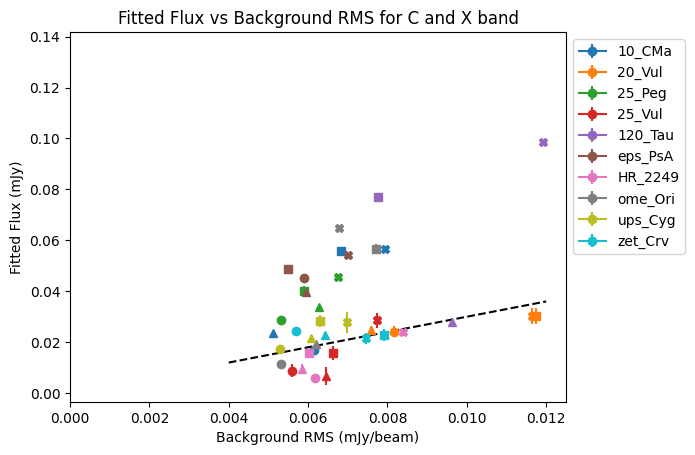

In [16]:

# with PdfPages(f'{outdir}Target_Fluxes.pdf') as pdf:
c_plots = []
color = cm.tab10(np.linspace(0, 1, len(source_list)))
for i, source in enumerate(source_list):
    print(f"Processing source {source}")
    target_dir = indir + source + '/'
    old_dir = indir + source + '_old/'
    # read in each ecsv in the target directory
    C_table = pd.read_csv(target_dir + f"{source}_C_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    X_table = pd.read_csv(target_dir + f"{source}_X_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    C_old_table = pd.read_csv(old_dir + f"{source}_C_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    X_old_table = pd.read_csv(old_dir + f"{source}_X_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    c_plot = plt.errorbar(C_table['src_bkg_rms_mean'].values[0], C_table['fit_amp'].values[0], yerr=C_table['fit_amp_err'].values[0], label='Data', color=color[i], marker='o')
    c_plots.append(c_plot)
    # c_plot.set_label(source)
    x_plot = plt.errorbar(X_table['src_bkg_rms_mean'].values[0], X_table['fit_amp'].values[0], yerr=X_table['fit_amp_err'].values[0], label='Data', color=color[i], marker='X')
    c_old_plot = plt.errorbar(C_old_table['src_bkg_rms_mean'].values[0], C_old_table['fit_amp'].values[0], yerr=C_old_table['fit_amp_err'].values[0], label='Old Data', color=color[i], marker='^')
    x_old_plot = plt.errorbar(X_old_table['src_bkg_rms_mean'].values[0], X_old_table['fit_amp'].values[0], yerr=X_old_table['fit_amp_err'].values[0], label='Old Data', color=color[i], marker='s')


    # read in the data for this source
    # do the analysis
    # save the results to outfile
snr_line = plt.plot([0.004,.012], [.012,.036], color='black', linestyle='--', label='SNR = 3')
c_plots.append(snr_line)
plt.xlabel('Background RMS (mJy/beam)')
plt.ylabel('Fitted Flux (mJy)')
plt.title('Fitted Flux vs Background RMS for C and X band')
plt.xlim(0, 0.0125)
leg_list = source_list + ['SNR = 3']
# print(leg_list)
plt.legend(c_plots, leg_list, loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig(outdir + 'Target_Fluxes.png', bbox_inches='tight', pad_inches=.3)
plt.show()

Processing source 10_CMa
Processing source 20_Vul
Processing source 25_Peg
Processing source 25_Vul
Processing source 120_Tau
Processing source eps_PsA
Processing source HR_2249
Processing source ome_Ori
Processing source ups_Cyg
Processing source zet_Crv


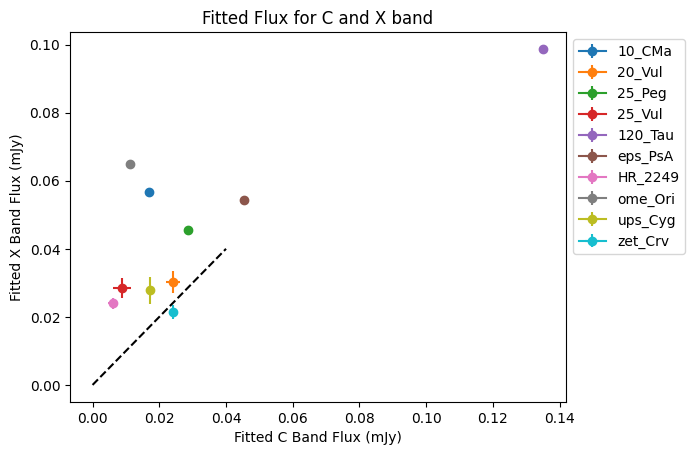

In [ ]:
# with PdfPages(f'{outdir}Target_Fluxes.pdf') as pdf:
c_plots = []
color = cm.tab10(np.linspace(0, 1, len(source_list)))
for i, source in enumerate(source_list):
    print(f"Processing source {source}")
    target_dir = indir + source + '/'
    # read in each ecsv in the target directory
    C_table = pd.read_csv(target_dir + f"{source}_C_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    X_table = pd.read_csv(target_dir + f"{source}_X_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    c_plot = plt.errorbar(C_table['fit_amp'].values[0], X_table['fit_amp'].values[0], xerr=C_table['fit_amp_err'].values[0], yerr=X_table['fit_amp_err'].values[0], label='Data', color=color[i], marker='o')
    c_plots.append(c_plot)
    # c_plot.set_label(source)
    # plt.scatter(X_table['src_bkg_rms_mean'].values[-1], X_table['fit_amp'].values[-1], label='Data', color=color[i], marker='X', s=100)


    # read in the data for this source
    # do the analysis
    # save the results to outfile
plt.plot([0,.04], [0,.04], color='black', linestyle='--')
# c_plots.append(snr_line)
plt.xlabel('Fitted C Band Flux (mJy)')
plt.ylabel('Fitted X Band Flux (mJy)')
plt.title('Fitted Flux for C and X band')
# leg_list = source_list + ['SNR = 5']
# print(leg_list)
plt.legend(c_plots, source_list, loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig(outdir + 'Target_Flux_Ratios.png', bbox_inches='tight', pad_inches=0.3)
plt.show()

#Check VLASS

Processing source 10_CMa
Processing source 20_Vul
Processing source 25_Peg
Processing source 25_Vul
Processing source 120_Tau
Processing source eps_PsA
Processing source HR_2249
Processing source ome_Ori
Processing source ups_Cyg
Processing source zet_Crv


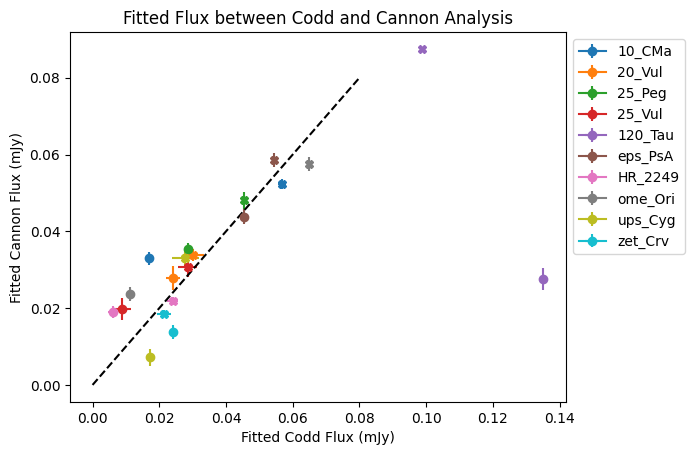

In [18]:
# with PdfPages(f'{outdir}Target_Fluxes.pdf') as pdf:
c_plots = []
color = cm.tab10(np.linspace(0, 1, len(source_list)))
for i, source in enumerate(source_list):
    print(f"Processing source {source}")
    target_dir = indir + source + '/'
    cannon_dir = indir + source + '_cannon/'
    # read in each ecsv in the target directory
    C_table = pd.read_csv(target_dir + f"{source}_C_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    C_cannon_table = pd.read_csv(cannon_dir + f"{source}_C_cannon_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    X_table = pd.read_csv(target_dir + f"{source}_X_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    X_cannon_table = pd.read_csv(cannon_dir + f"{source}_X_cannon_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    c_plot = plt.errorbar(C_table['fit_amp'].values[0], C_cannon_table['fit_amp'].values[0], xerr=C_table['fit_amp_err'].values[0], yerr=C_cannon_table['fit_amp_err'].values[0], label='Data', color=color[i], marker='o')
    x_plot = plt.errorbar(X_table['fit_amp'].values[0], X_cannon_table['fit_amp'].values[0], xerr=X_table['fit_amp_err'].values[0], yerr=X_cannon_table['fit_amp_err'].values[0], label='Data', color=color[i], marker='X')
    c_plots.append(c_plot)
    # c_plot.set_label(source)
    # plt.scatter(X_table['src_bkg_rms_mean'].values[-1], X_table['fit_amp'].values[-1], label='Data', color=color[i], marker='X', s=100)


    # read in the data for this source
    # do the analysis
    # save the results to outfile
plt.plot([0,.08], [0,.08], color='black', linestyle='--')
# c_plots.append(snr_line)
plt.xlabel('Fitted Codd Flux (mJy)')
plt.ylabel('Fitted Cannon Flux (mJy)')
plt.title('Fitted Flux between Codd and Cannon Analysis')
# leg_list = source_list + ['SNR = 5']
# print(leg_list)
plt.legend(c_plots, source_list, loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig(outdir + 'Cannon_Codd_Flux_Comparison.png', bbox_inches='tight', pad_inches=0.3)
plt.show()

Processing source 10_CMa
Processing source 20_Vul
Processing source 25_Peg
Processing source 25_Vul
Processing source 120_Tau
Processing source eps_PsA
Processing source HR_2249
Processing source ome_Ori
Processing source ups_Cyg
Processing source zet_Crv


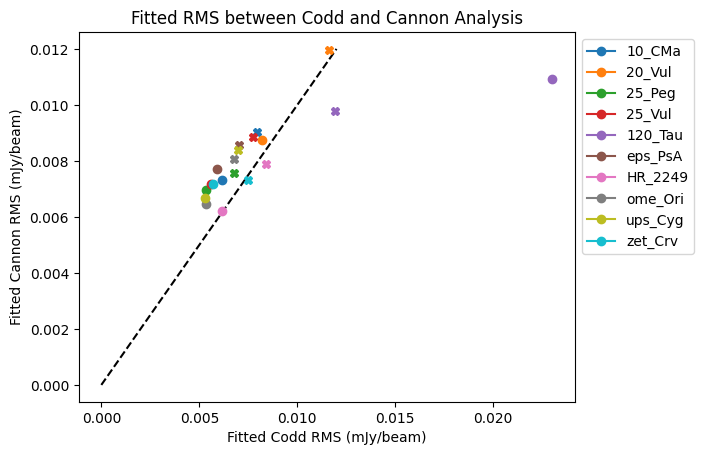

In [19]:
# with PdfPages(f'{outdir}Target_Fluxes.pdf') as pdf:
c_plots = []
color = cm.tab10(np.linspace(0, 1, len(source_list)))
for i, source in enumerate(source_list):
    print(f"Processing source {source}")
    target_dir = indir + source + '/'
    cannon_dir = indir + source + '_cannon/'
    # read in each ecsv in the target directory
    C_table = pd.read_csv(target_dir + f"{source}_C_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    C_cannon_table = pd.read_csv(cannon_dir + f"{source}_C_cannon_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    X_table = pd.read_csv(target_dir + f"{source}_X_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    X_cannon_table = pd.read_csv(cannon_dir + f"{source}_X_cannon_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    c_plot = plt.errorbar(C_table['src_bkg_rms_mean'].values[0], C_cannon_table['src_bkg_rms_mean'].values[0], label='Data', color=color[i], marker='o')
    x_plot = plt.errorbar(X_table['src_bkg_rms_mean'].values[0], X_cannon_table['src_bkg_rms_mean'].values[0],  label='Data', color=color[i], marker='X')
    c_plots.append(c_plot)
    # c_plot.set_label(source)
    # plt.scatter(X_table['src_bkg_rms_mean'].values[-1], X_table['fit_amp'].values[-1], label='Data', color=color[i], marker='X', s=100)


    # read in the data for this source
    # do the analysis
    # save the results to outfile
plt.plot([0,.012], [0,.012], color='black', linestyle='--')
# c_plots.append(snr_line)
plt.xlabel('Fitted Codd RMS (mJy/beam)')
plt.ylabel('Fitted Cannon RMS (mJy/beam)')
plt.title('Fitted RMS between Codd and Cannon Analysis')
# leg_list = source_list + ['SNR = 5']
# print(leg_list)
plt.legend(c_plots, source_list, loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig(outdir + 'Cannon_Codd_RMS_Comparison.png', bbox_inches='tight', pad_inches=0.3)
plt.show()

# IR Comparison

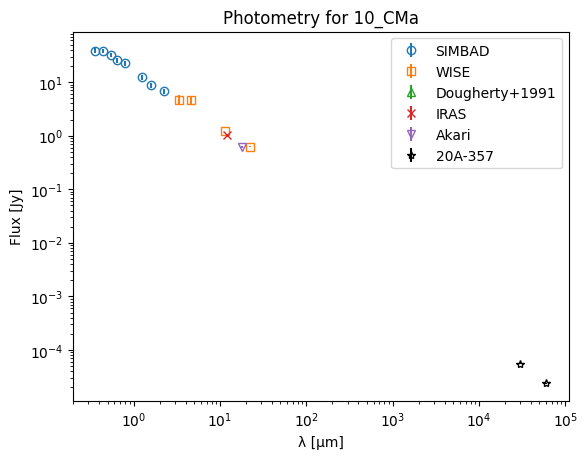

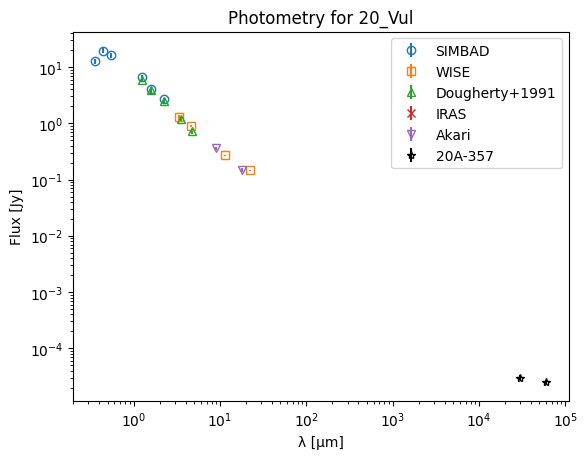

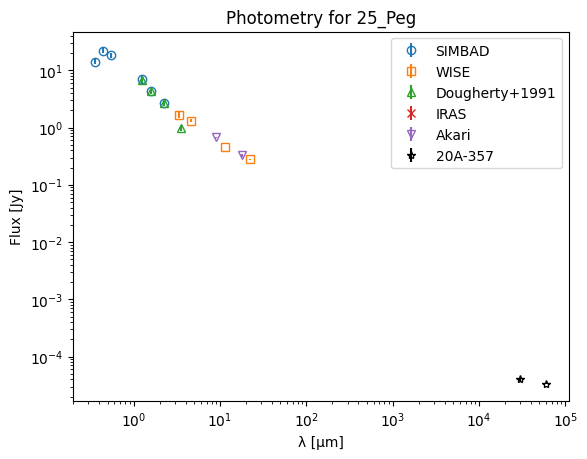

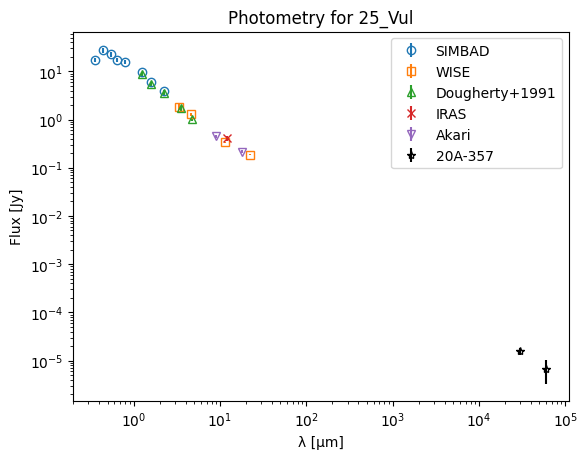

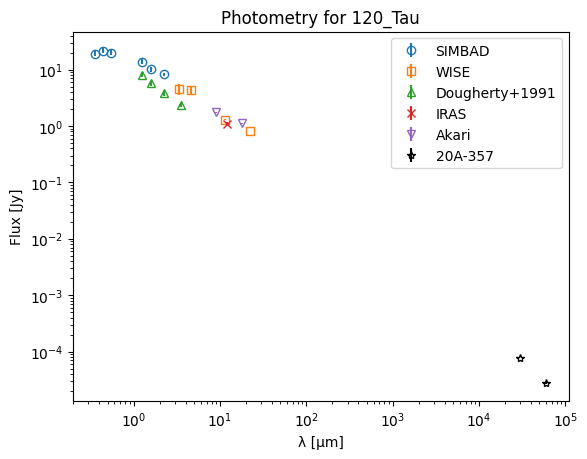

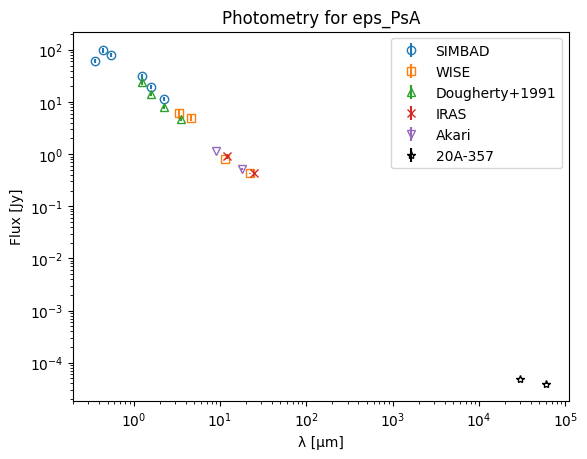

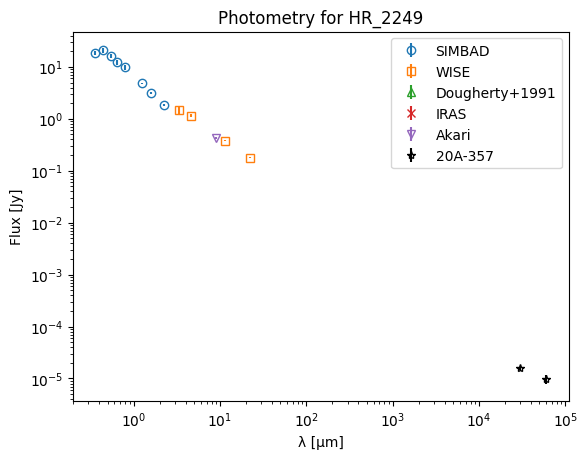

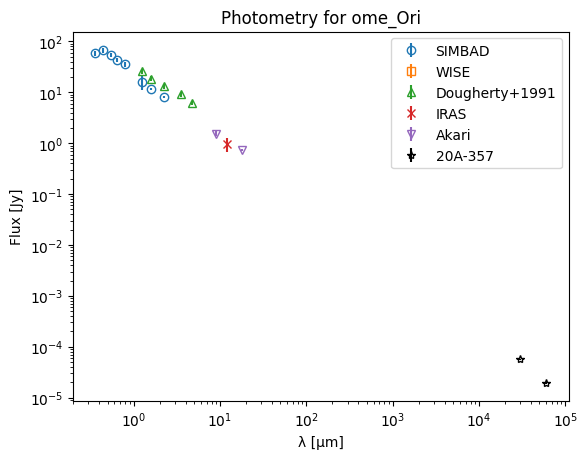

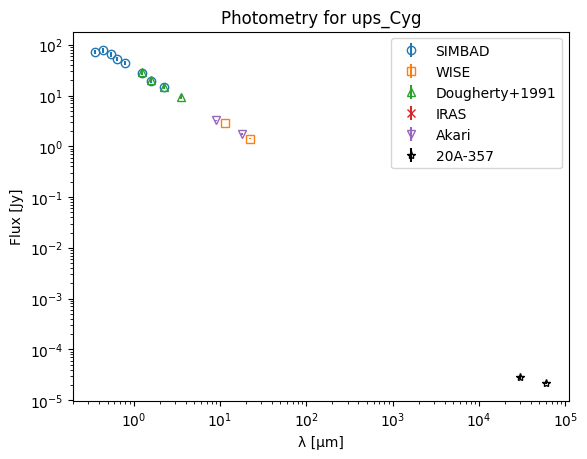

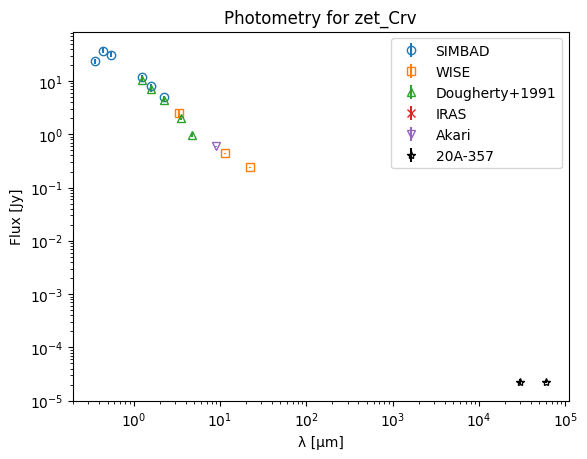

In [21]:
for i, source in enumerate(source_list):
    target_dir = indir + source + '_Old/'
    file_path = target_dir + diff_source_list[i] + '_photometry.dat'
    # Assuming data is in a structured format like CSV or similar
    df = pd.read_csv(file_path, delimiter=' ')  # Adjust delimiter if necessary
    C_table = pd.read_csv(target_dir + f"{source}_C_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    X_table = pd.read_csv(target_dir + f"{source}_X_fitted_source_catalog.ecsv", comment='#', delimiter=' ')
    # Process the DataFrame
    simbad = df[df['Survey'] == 'simbad']
    wise = df[df['Survey'] == 'wise']
    dougherty = df[df['Survey'] == 'dougherty+1991']
    akari = df[df['Survey'] == 'akari']
    iras = df[df['Survey'] == 'iras']
    plt.errorbar(simbad['Wavelength'].values, simbad['Flux'].values, yerr=simbad['Flux_Error'].values, marker='o', linestyle='None', label='SIMBAD', fillstyle='none')
    plt.errorbar(wise['Wavelength'].values, wise['Flux'].values, yerr=wise['Flux_Error'].values, marker='s', linestyle='None', label='WISE', fillstyle='none')
    plt.errorbar(dougherty['Wavelength'].values, dougherty['Flux'].values, yerr=dougherty['Flux_Error'].values, marker='^', linestyle='None', label='Dougherty+1991', fillstyle='none')
    plt.errorbar(iras['Wavelength'].values, iras['Flux'].values, yerr=iras['Flux_Error'].values, marker='x', linestyle='None', label='IRAS', fillstyle='none')
    plt.errorbar(akari['Wavelength'].values, akari['Flux'].values, yerr=akari['Flux_Error'].values, marker='v', linestyle='None', label='Akari', fillstyle='none')
    plt.errorbar(60000, C_table['fit_amp'].values[0]/1000, yerr=C_table['fit_amp_err'].values[0]/1000, marker='*', linestyle='None', label='20A-357', fillstyle='none', color = 'black')
    plt.errorbar(30000, X_table['fit_amp'].values[0]/1000, yerr=X_table['fit_amp_err'].values[0]/1000, marker='*', linestyle='None', fillstyle='none', color = 'black')
    plt.xlabel('λ [μm]')
    plt.ylabel('Flux [Jy]')
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.title(f'Photometry for {source}')
    plt.savefig(outdir + f'{source}_photometry.png', bbox_inches='tight', pad_inches=0.3)
    plt.show()

In [ ]:
def plot_photometry_with_fit(
    indir,
    outdir,
    source,
    photometry_name=None,
    fit_survey=None,
    fit_in_loglog=False,
    fit_err=False,
    show_plot=True,
    save_plot=True
):
    """
    Plot photometry from multiple surveys and optionally fit one or more surveys.

    Parameters
    ----------
    indir : str
        Base input directory.
    outdir : str
        Output directory.
    source : str
        Source name.
    photometry_name : str or None
        Prefix for photometry filename. If None, defaults to `source`.
    fit_survey : str, list of str, or None
        Survey name(s) to fit, e.g. 'simbad' or ['simbad', 'wise'].
    fit_in_loglog : bool
        If True, fit log10(Flux) vs log10(Wavelength).
    fit_err : bool
        If True, draw a 1-sigma band around each fit.
    show_plot : bool
        If True, display plot.
    save_plot : bool
        If True, save plot.

    Returns
    -------
    dict
        {
            "df": full DataFrame,
            "surveys": dict of survey DataFrames,
            "fits": list of fit result dicts
        }
    """

    if photometry_name is None:
        photometry_name = source

    target_dir = os.path.join(indir, source + '_Old')
    file_path = os.path.join(target_dir, f"{photometry_name}_photometry.dat")
    c_path = os.path.join(target_dir, f"{source}_C_fitted_source_catalog.ecsv")
    x_path = os.path.join(target_dir, f"{source}_X_fitted_source_catalog.ecsv")

    df = pd.read_csv(file_path, delim_whitespace=True)
    C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
    X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)

    surveys = {
        "simbad": df[df["Survey"] == "simbad"],
        "wise": df[df["Survey"] == "wise"],
        "dougherty+1991": df[df["Survey"] == "dougherty+1991"],
        "akari": df[df["Survey"] == "akari"],
        "iras": df[df["Survey"] == "iras"],
    }

    plot_styles = {
        "simbad": {"marker": "o", "label": "SIMBAD"},
        "wise": {"marker": "s", "label": "WISE"},
        "dougherty+1991": {"marker": "^", "label": "Dougherty+1991"},
        "iras": {"marker": "x", "label": "IRAS"},
        "akari": {"marker": "v", "label": "Akari"},
    }


    plt.figure(figsize=(12, 6))

    # Plot survey points
    for survey_name, survey_df in surveys.items():
        if not survey_df.empty:
            style = plot_styles[survey_name]
            plt.errorbar(
                survey_df["Wavelength"].values,
                survey_df["Flux"].values,
                yerr=survey_df["Flux_Error"].values,
                marker=style["marker"],
                linestyle="None",
                label=style["label"],
                fillstyle="none"
            )

    # Plot extra catalog points
    extra_x = []
    extra_y = []

    if not C_table.empty:
        x_c = 60000.0
        y_c = C_table["fit_amp"].values[0] / 1000.0
        plt.errorbar(
            x_c,
            y_c,
            yerr=C_table["fit_amp_err"].values[0] / 1000.0,
            marker="*",
            linestyle="None",
            label="20A-357",
            fillstyle="none",
            color="black"
        )
        extra_x.append(x_c)
        extra_y.append(y_c)

    if not X_table.empty:
        x_x = 30000.0
        y_x = X_table["fit_amp"].values[0] / 1000.0
        plt.errorbar(
            x_x,
            y_x,
            yerr=X_table["fit_amp_err"].values[0] / 1000.0,
            marker="*",
            linestyle="None",
            fillstyle="none",
            color="black"
        )
        extra_x.append(x_x)
        extra_y.append(y_x)

    # Determine full plot x-range from all plotted points
    all_x = df["Wavelength"].values.astype(float)
    all_y = df["Flux"].values.astype(float)

    if extra_x:
        all_x = np.concatenate([all_x, np.array(extra_x, dtype=float)])
    if extra_y:
        all_y = np.concatenate([all_y, np.array(extra_y, dtype=float)])

    positive_x = all_x[all_x > 0]

    if len(positive_x) > 0:
        x_plot_min = positive_x.min()
        x_plot_max = positive_x.max()
    else:
        x_plot_min, x_plot_max = 1.0, 10.0

    # Normalize fit_survey to a list
    if fit_survey is None:
        fit_surveys = []
    elif isinstance(fit_survey, str):
        fit_surveys = [fit_survey]
    else:
        fit_surveys = list(fit_survey)

    fit_results = []

    # Fit each requested survey
    for survey_name in fit_surveys:
        if survey_name not in surveys:
            raise ValueError(
                f"fit_survey='{survey_name}' not recognized. "
                f"Choose from: {list(surveys.keys())}"
            )

        fit_df = surveys[survey_name].copy()

        if len(fit_df) < 2:
            print(f"Not enough points to fit survey '{survey_name}'. Need at least 2.")
            continue

        x = fit_df["Wavelength"].values.astype(float)
        y = fit_df["Flux"].values.astype(float)

        if fit_in_loglog:
            mask = (x > 0) & (y > 0)
            x = x[mask]
            y = y[mask]

            if len(x) < 2:
                print(f"Not enough positive points to log-log fit survey '{survey_name}'.")
                continue

            x_fit = np.log10(x)
            y_fit = np.log10(y)

            slope, intercept = np.polyfit(x_fit, y_fit, 1)

            # residual scatter in log space
            y_model_fit = slope * x_fit + intercept
            sigma = np.std(y_fit - y_model_fit, ddof=1) if len(y_fit) > 2 else 0.0

            # Start from earliest point in this survey, extend to full plot max
            x_fit_min = x.min()
            x_line = np.logspace(np.log10(x_fit_min), np.log10(x_plot_max), 500)

            log_y_line = slope * np.log10(x_line) + intercept
            y_line = 10 ** log_y_line

            plt.plot(
                x_line,
                y_line,
                "--",
                label=f"{survey_name} fit (log-log)"
            )

            if fit_err and sigma > 0:
                y_lower = 10 ** (log_y_line - sigma)
                y_upper = 10 ** (log_y_line + sigma)
                plt.fill_between(
                    x_line,
                    y_lower,
                    y_upper,
                    alpha=0.2
                )

            fit_results.append({
                "survey": survey_name,
                "space": "log-log",
                "slope": slope,
                "intercept": intercept,
                "sigma": sigma,
                "x_start": x_fit_min,
                "x_end": x_plot_max
            })

        else:
            slope, intercept = np.polyfit(x, y, 1)

            # residual scatter in linear space
            y_model_fit = slope * x + intercept
            sigma = np.std(y - y_model_fit, ddof=1) if len(y) > 2 else 0.0

            # Start from earliest point in this survey, extend to full plot max
            x_fit_min = x.min()
            x_line = np.logspace(np.log10(x_fit_min), np.log10(x_plot_max), 500)
            y_line = slope * x_line + intercept

            # only plot positive values because y-axis is log
            valid = y_line > 0
            plt.plot(
                x_line[valid],
                y_line[valid],
                "--",
                label=f"{survey_name} fit"
            )

            if fit_err and sigma > 0:
                y_lower = y_line - sigma
                y_upper = y_line + sigma
                valid_band = (y_lower > 0) & (y_upper > 0)
                plt.fill_between(
                    x_line[valid_band],
                    y_lower[valid_band],
                    y_upper[valid_band],
                    alpha=0.2
                )

            fit_results.append({
                "survey": survey_name,
                "space": "linear",
                "slope": slope,
                "intercept": intercept,
                "sigma": sigma,
                "x_start": x_fit_min,
                "x_end": x_plot_max
            })

    plt.xlabel("λ [μm]")
    plt.ylabel("Flux [Jy]")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.title(f"Photometry for {source}")

    if save_plot:
        os.makedirs(outdir, exist_ok=True)
        save_path = os.path.join(outdir, f"{source}_photometry.png")
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0.3)

    if show_plot:
        plt.show()
    else:
        plt.close()

    return {
        "df": df,
        "surveys": surveys,
        "fits": fit_results
    }

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'akari'. Need at least 2.


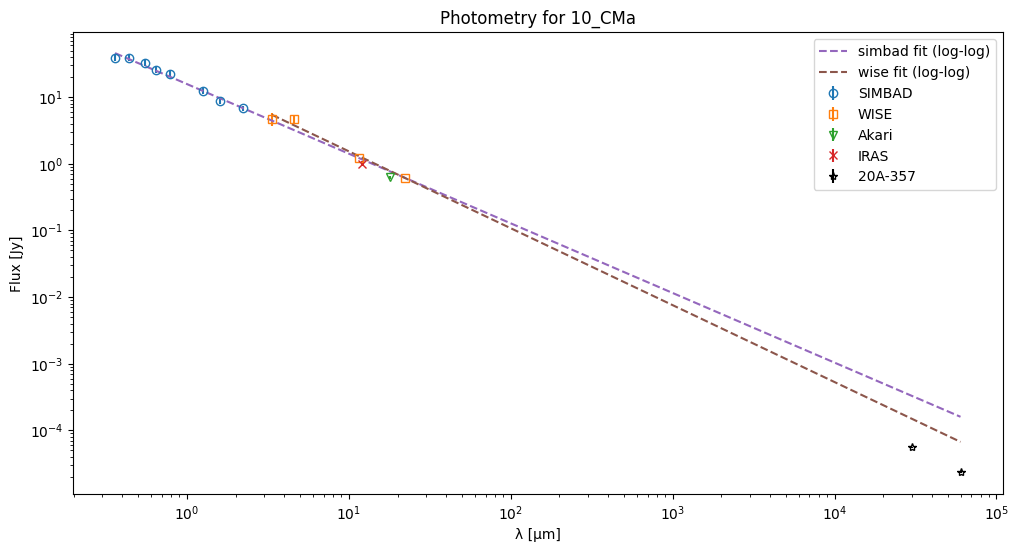

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


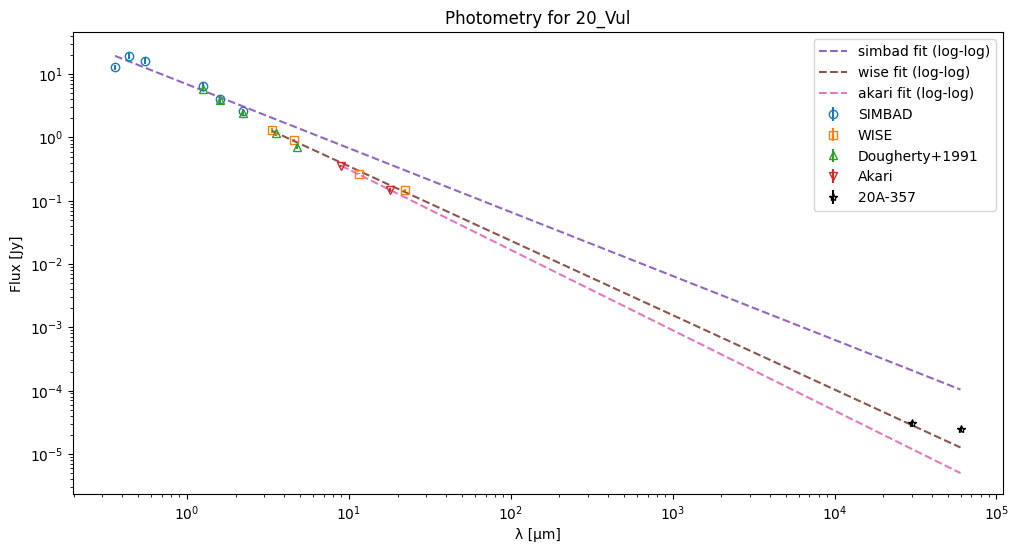

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


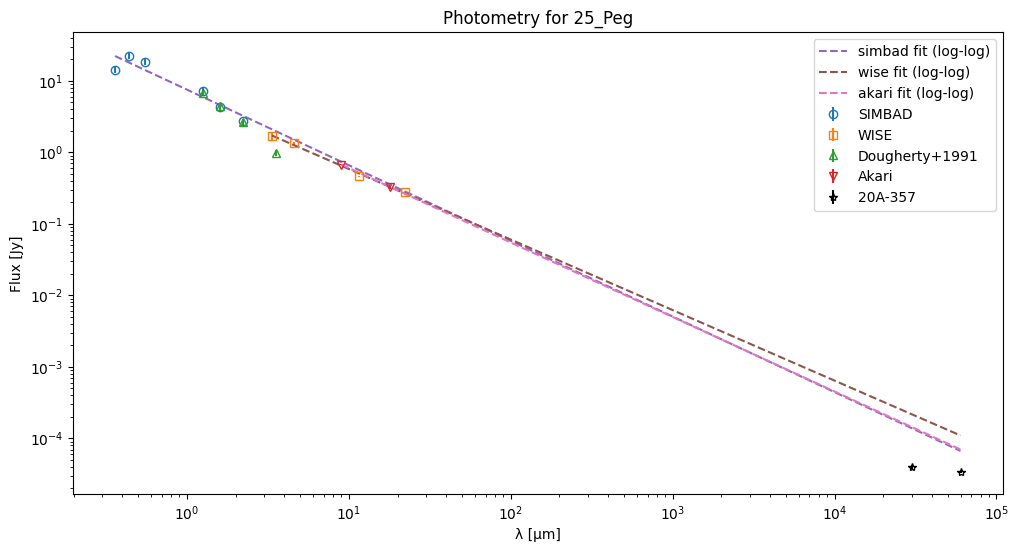

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


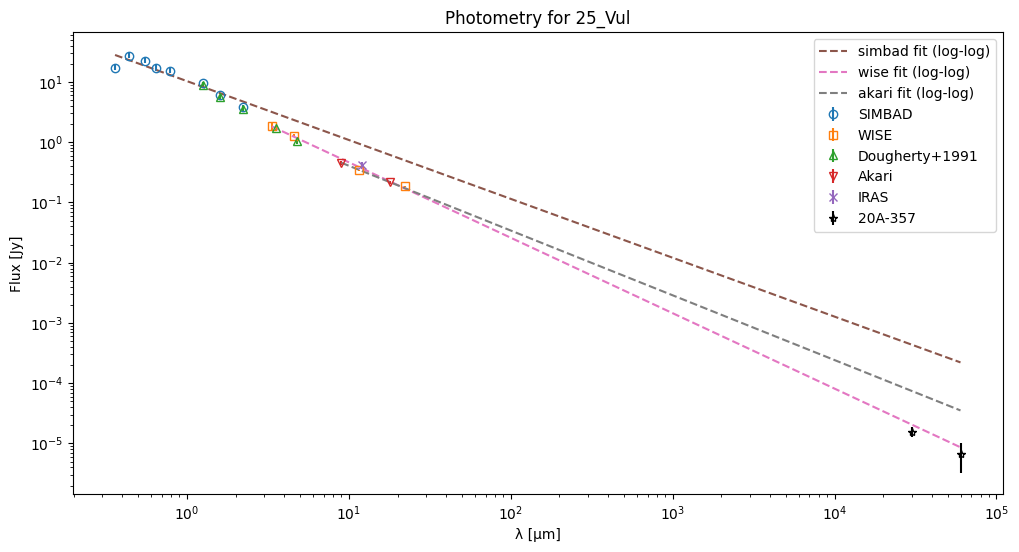

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


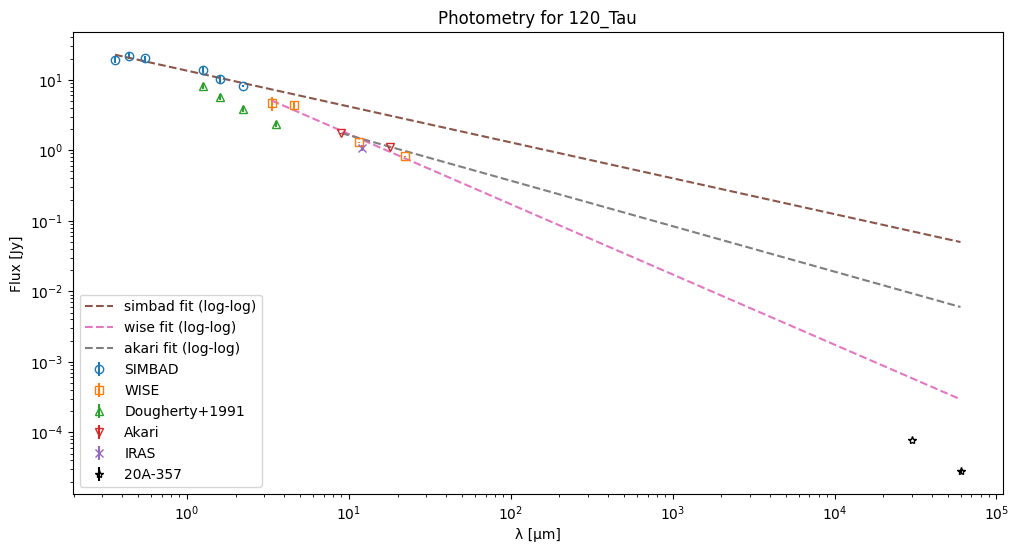

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


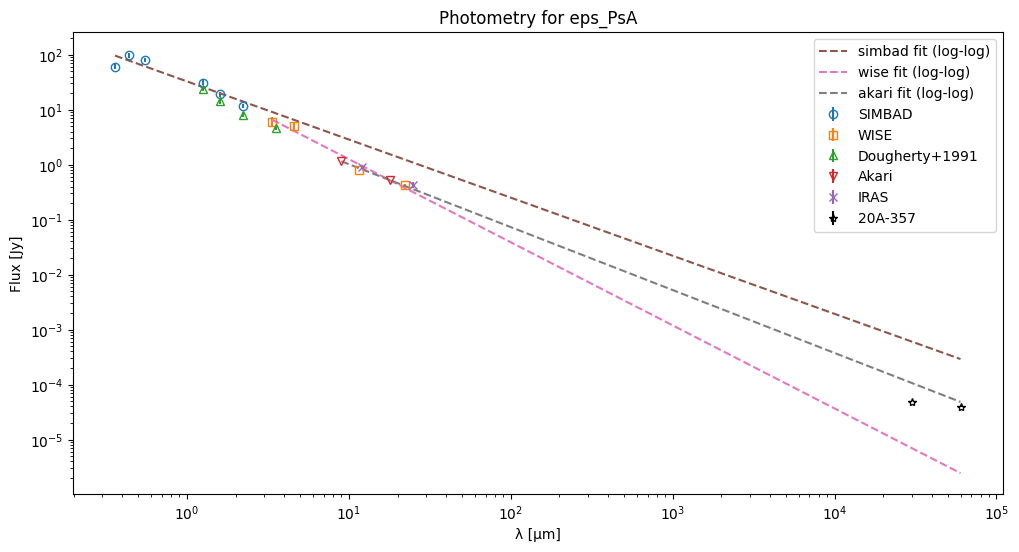

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'akari'. Need at least 2.


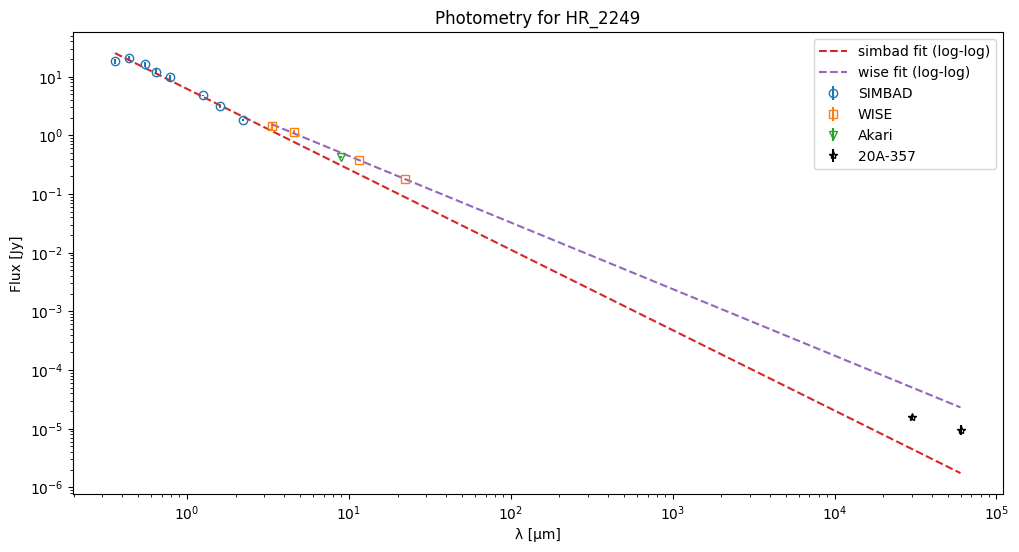

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'wise'. Need at least 2.


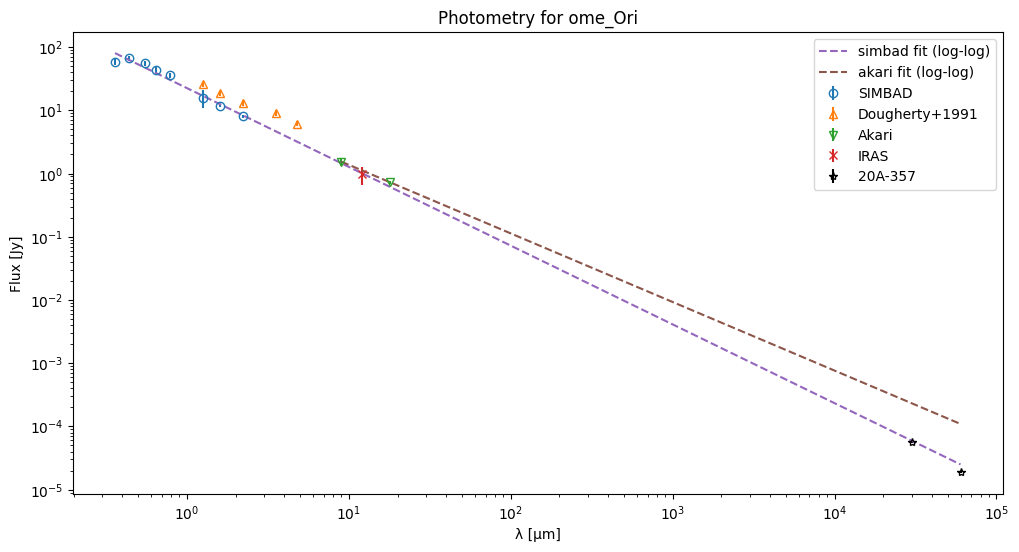

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


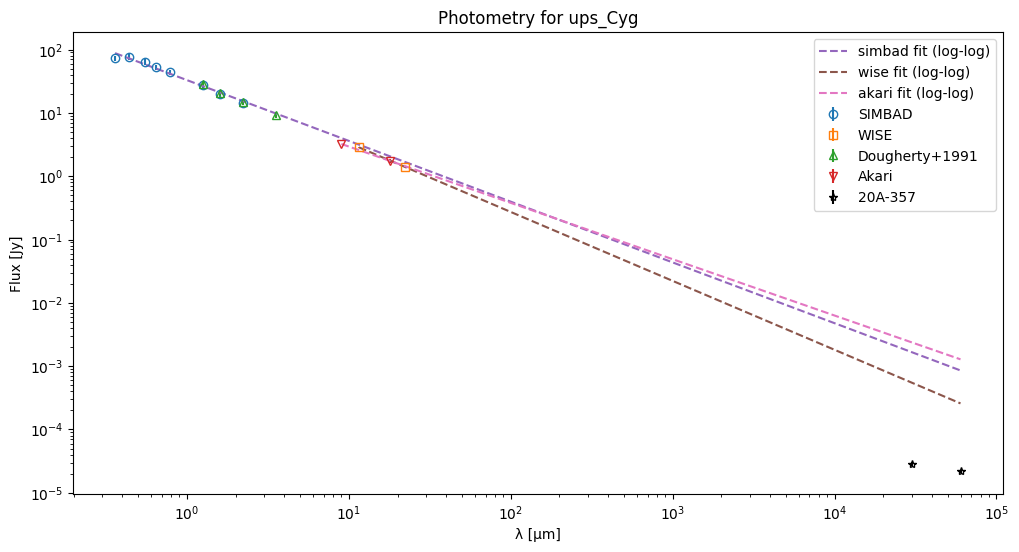

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:54: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:55: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2973338978.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'akari'. Need at least 2.


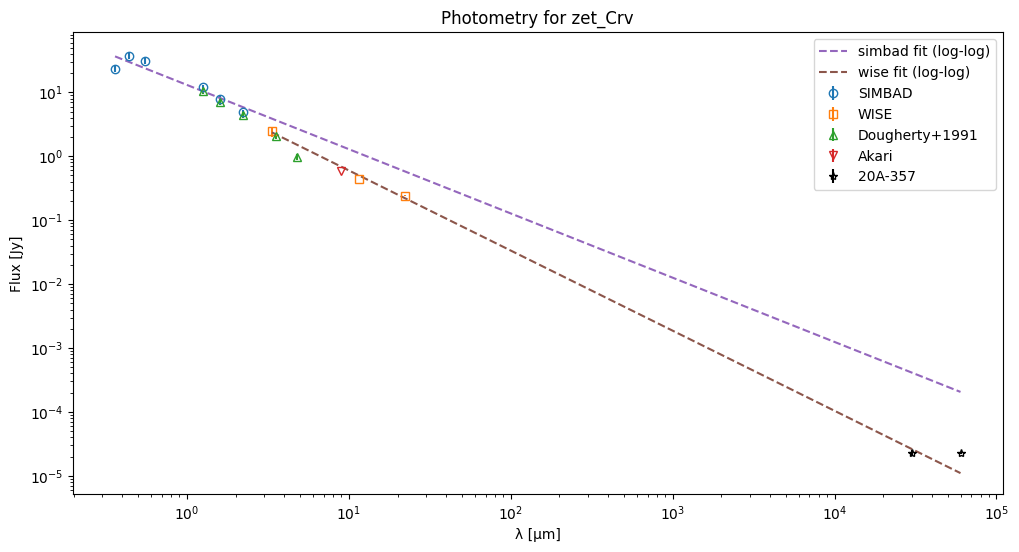

In [23]:
for i in range(len(source_list)):

    result = plot_photometry_with_fit(
        indir=indir,
        outdir=outdir,
        source=source_list[i],
        photometry_name=diff_source_list[i],
        fit_survey=['simbad','wise', 'akari'],
        fit_in_loglog=True,
        fit_err=False,
    )

    # print(result["fit"])

In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Vieira et al. (2015) Appendix A coefficients used by Klement et al. (2019)
# log(T/K), G0, G1, G2, B0, B1, B2
# See https://academic.oup.com/mnras/article/454/2/2107/2892549#78673700 for table, also gives T_d/T_eff = 0.6, beta = 1.5
GAUNT_TABLE = [
    (3.70, 0.0952, 0.0215, 0.0145,  2.2125, -1.5290, 0.0563),
    (3.82, 0.1001, 0.0421, 0.0130,  1.6304, -1.3884, 0.0413),
    (3.94, 0.1097, 0.0639, 0.0111,  1.1316, -1.2866, 0.0305),
    (4.06, 0.1250, 0.0858, 0.0090,  0.6927, -1.2128, 0.0226),
    (4.18, 0.1470, 0.1071, 0.0068,  0.2964, -1.1585, 0.0169),
    (4.30, 0.1761, 0.1269, 0.0046, -0.0690, -1.1185, 0.0126),
]


def _power_law_lambda(wavelength, A, kappa):
    """F_nu = A * lambda^(-kappa)"""
    return A * wavelength ** (-kappa)


def _nearest_gaunt_row(logT):
    rows = np.array(GAUNT_TABLE, dtype=float)
    idx = np.argmin(np.abs(rows[:, 0] - logT))
    return rows[idx]


def _compute_u_vieira(teff, wavelength_um=15.0):
    """
    Compute u = d ln(g+b) / d ln(lambda) using Vieira et al. (2015) Appendix A,
    following the setup used by Klement et al. (2019):
    T_disk = 0.6 * T_eff, representative wavelength = 15 micron.
    """
    t_disk = 0.6 * teff
    logT = np.log10(t_disk)

    _, G0, G1, G2, B0, B1, B2 = _nearest_gaunt_row(logT)
    lnlam = np.log(wavelength_um)

    g = np.exp(G0 + G1 * lnlam + G2 * lnlam**2)
    b = np.exp(B0 + B1 * lnlam + B2 * lnlam**2)

    u = ((G1 + 2 * G2 * lnlam) * g + (B1 + 2 * B2 * lnlam) * b) / (g + b)
    return float(u), float(t_disk)


def _compute_n_from_kappa(kappa, teff, beta=1.5, wavelength_um=15.0): # 15 micron is representative MIR wavelength
    """
    From Klement et al. (2019) / Vieira et al. (2015):
        alpha_IR = kappa + 2
        alpha_IR = 4 - (4 + 2u) / (2n - beta)

    Solve for n:
        n = [beta + (4 + 2u)/(4 - alpha_IR)] / 2
          = [beta + (4 + 2u)/(2 - kappa)] / 2
    """
    u, t_disk = _compute_u_vieira(teff=teff, wavelength_um=wavelength_um)
    alpha_ir = kappa + 2.0

    denom = 4.0 - alpha_ir  # = 2 - kappa
    if np.isclose(denom, 0.0):
        return np.nan, u, t_disk, alpha_ir

    n = (beta + (4.0 + 2.0 * u) / denom) / 2.0
    return float(n), float(u), float(t_disk), float(alpha_ir)

def _make_radio_df_from_tables(ku_tables):
    rows = []
    for ku_table in ku_tables:
        if not ku_table.empty:
            freq_ghz = ku_table["freq"].values[0]
            wavelength_um = (2.998e8 / (freq_ghz * 1e9)) * 1e6
            flux_jy = ku_table["fit_amp"].values[0] / 1000.0
            flux_err_jy = ku_table["fit_amp_err"].values[0] / 1000.0
            rows.append({
                "Survey": "VLA Ku-band",
                "Wavelength": wavelength_um,
                "Flux": flux_jy,
                "Flux_Error": flux_err_jy,
            })

    return pd.DataFrame(rows)


def plot_photometry_with_fit(
    indir,
    outdir,
    source,
    photometry_name=None,
    fit_survey=None,
    fit_in_loglog=False,
    fit_err=False,
    teff=None,
    show_powerlaw_coeffs=True,
    annotate_powerlaw=True,
    show_plot=True,
    save_plot=True
):
    """
    Plot photometry and optionally fit one or more surveys.

    Parameters
    ----------
    indir, outdir, source : str
    photometry_name : str or None
    fit_survey : str, list[str], or None
    fit_in_loglog : bool
        If True, fit straight lines in log-log space.
        If False, fit F_nu = A * lambda^(-kappa) directly.
    fit_err : bool
        If True, draw a 1-sigma band around each fit.
    teff : float or None
        Effective temperature in K. Needed to compute paper-style n.
    show_powerlaw_coeffs : bool
        If True, compute and return kappa, alpha_IR, and n (when possible).
    annotate_powerlaw : bool
        If True, write fitted coefficients on the plot.
    """

    if photometry_name is None:
        photometry_name = source

    if source in source_list:
        target_dir = os.path.join(indir, source + '_Old')
        new_target_dir = os.path.join(indir, source)
        file_path = os.path.join(target_dir, f"{photometry_name}_photometry.dat")
        c_path = os.path.join(new_target_dir, f"{source}_C_fitted_source_catalog.ecsv")
        x_path = os.path.join(new_target_dir, f"{source}_X_fitted_source_catalog.ecsv")
        df = pd.read_csv(file_path, delim_whitespace=True)
        C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
        X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)
    if source == 'HD44637':
        target_dir = indir
        file_path = os.path.join(target_dir, f"{photometry_name}_photometry.dat")
        Ku1_path = os.path.join(target_dir, f"{source}_12-13GHz/{source}_12-13GHz_fitted_source_catalog.ecsv")
        Ku2_path = os.path.join(target_dir, f"{source}_13-14GHz/{source}_13-14GHz_fitted_source_catalog.ecsv")
        Ku3_path = os.path.join(target_dir, f"{source}_14-15GHz/{source}_14-15GHz_fitted_source_catalog.ecsv")
        Ku4_path = os.path.join(target_dir, f"{source}_15-16GHz/{source}_15-16GHz_fitted_source_catalog.ecsv")
        Ku5_path = os.path.join(target_dir, f"{source}_16-17GHz/{source}_16-17GHz_fitted_source_catalog.ecsv")
        Ku6_path = os.path.join(target_dir, f"{source}_17-18GHz/{source}_17-18GHz_fitted_source_catalog.ecsv")
        df = pd.read_csv(file_path, delim_whitespace=True)
        Ku1_table = pd.read_csv(Ku1_path, comment="#", delim_whitespace=True)
        Ku2_table = pd.read_csv(Ku2_path, comment="#", delim_whitespace=True)
        Ku3_table = pd.read_csv(Ku3_path, comment="#", delim_whitespace=True)
        Ku4_table = pd.read_csv(Ku4_path, comment="#", delim_whitespace=True)
        Ku5_table = pd.read_csv(Ku5_path, comment="#", delim_whitespace=True)
        Ku6_table = pd.read_csv(Ku6_path, comment="#", delim_whitespace=True)

    surveys = {
        "simbad": df[df["Survey"] == "simbad"],
        "wise": df[df["Survey"] == "wise"],
        "dougherty+1991": df[df["Survey"] == "dougherty+1991"],
        "akari": df[df["Survey"] == "akari"],
        "iras": df[df["Survey"] == "iras"],
        "VLA Ku-band": _make_radio_df_from_tables([Ku1_table, Ku2_table, Ku3_table, Ku4_table, Ku5_table, Ku6_table]) if source == 'HD44637' else pd.DataFrame(columns=["Survey", "Wavelength", "Flux", "Flux_Error"]),
    }

    plot_styles = {
        "simbad": {"marker": "o", "label": "SIMBAD"},
        "wise": {"marker": "s", "label": "WISE"},
        "dougherty+1991": {"marker": "^", "label": "Dougherty+1991"},
        "iras": {"marker": "x", "label": "IRAS"},
        "akari": {"marker": "v", "label": "Akari"},
        "VLA Ku-band": {"marker": "*", "label": "VLA Ku-band"},
    }

    plt.figure(figsize=(12, 6))

    for survey_name, survey_df in surveys.items():
        if not survey_df.empty:
            style = plot_styles[survey_name]
            plt.errorbar(
                survey_df["Wavelength"].values,
                survey_df["Flux"].values,
                yerr=survey_df["Flux_Error"].values,
                marker=style["marker"],
                linestyle="None",
                label=style["label"],
                fillstyle="none"
            )

    extra_x = []
    extra_y = []

    if source in source_list:
        if not C_table.empty:
            x_c = 60000.0 # Representative wavelength for C band point, in microns
            y_c = C_table["fit_amp"].values[0] / 1000.0
            plt.errorbar(x_c, y_c, yerr=C_table["fit_amp_err"].values[0] / 1000.0, marker="*",
                linestyle="None", label="20A-357", fillstyle="none", color="black"
            )
            extra_x.append(x_c)
            extra_y.append(y_c)

        if not X_table.empty:
            x_x = 30000.0 # Representative wavelength for X band point, in microns
            y_x = X_table["fit_amp"].values[0] / 1000.0
            plt.errorbar(
                x_x, y_x, yerr=X_table["fit_amp_err"].values[0] / 1000.0, marker="*",
                linestyle="None", fillstyle="none", color="black"
            )
            extra_x.append(x_x)
            extra_y.append(y_x)
    if source == 'HD44637':
        ku_tables = [Ku1_table, Ku2_table, Ku3_table, Ku4_table, Ku5_table, Ku6_table]
        ku_df = _make_radio_df_from_tables(ku_tables)
        for i, ku_table in enumerate(ku_tables):
            if not ku_table.empty:
                x_ku = (2.998e8 / (ku_table["freq"].values[0]*1e9))*1e6 # convert GHz to microns
                y_ku = ku_table["fit_amp"].values[0] / 1000.0
                plt.errorbar(
                    x_ku, y_ku, yerr=ku_table["fit_amp_err"].values[0] / 1000.0, marker="*",
                    linestyle="None", label=f"VLA Ku Band" if i == 0 else None, fillstyle="none", color="black"
                )
                extra_x.append(x_ku)
                extra_y.append(y_ku)

    all_x = df["Wavelength"].values.astype(float)
    if extra_x:
        all_x = np.concatenate([all_x, np.array(extra_x, dtype=float)])

    positive_x = all_x[all_x > 0]
    if len(positive_x) > 0:
        x_plot_max = positive_x.max()
    else:
        x_plot_max = 10.0

    if fit_survey is None:
        fit_surveys = []
    elif isinstance(fit_survey, str):
        fit_surveys = [fit_survey]
    else:
        fit_surveys = list(fit_survey)

    fit_results = []
    annotation_lines = []

    for survey_name in fit_surveys:
        if survey_name not in surveys:
            raise ValueError(
                f"fit_survey='{survey_name}' not recognized. "
                f"Choose from: {list(surveys.keys())}"
            )

        fit_df = surveys[survey_name].copy()
        if len(fit_df) < 2:
            print(f"Not enough points to fit survey '{survey_name}'. Need at least 2.")
            continue

        x = fit_df["Wavelength"].values.astype(float)
        y = fit_df["Flux"].values.astype(float)
        yerr = fit_df["Flux_Error"].values.astype(float)

        mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
        if fit_in_loglog:
            mask &= (yerr > 0) & np.isfinite(yerr)

        x = x[mask]
        y = y[mask]
        yerr = yerr[mask]

        if len(x) < 2:
            print(f"Not enough valid points to fit survey '{survey_name}'.")
            continue

        x_fit_min = x.min()
        x_line = np.logspace(np.log10(x_fit_min), np.log10(x_plot_max), 500)

        if fit_in_loglog:
            logx = np.log10(x)
            logy = np.log10(y)

            # propagate sigma_y to sigma_log10y
            sigma_logy = yerr / (y * np.log(10))
            sigma_logy = np.where(sigma_logy <= 0, np.nanmedian(sigma_logy[sigma_logy > 0]), sigma_logy)

            coeffs = np.polyfit(logx, logy, 1, w=1 / sigma_logy)
            slope, intercept = coeffs

            # log10(F) = intercept + slope * log10(lambda)
            # Paper convention: F_nu ∝ lambda^{-kappa}
            kappa = -slope
            A = 10**intercept

            logy_fit = intercept + slope * logx
            sigma = np.std(logy - logy_fit, ddof=1) if len(logy) > 2 else 0.0

            logy_line = intercept + slope * np.log10(x_line)
            y_line = 10**logy_line

            plt.plot(x_line, y_line, "--", label=f"{survey_name} fit")

            if fit_err and sigma > 0:
                y_lower = 10**(logy_line - sigma)
                y_upper = 10**(logy_line + sigma)
                plt.fill_between(x_line, y_lower, y_upper, alpha=0.2)

        else:
            # direct weighted fit to F_nu = A * lambda^{-kappa}
            p0 = [np.nanmax(y), 1.0]

            try:
                popt, pcov = curve_fit(
                    _power_law_lambda,
                    x,
                    y,
                    sigma=yerr,
                    absolute_sigma=True,
                    p0=p0,
                    maxfev=10000
                )
                A, kappa = popt
            except Exception:
                print(f"Power-law fit failed for survey '{survey_name}'.")
                continue

            y_fit = _power_law_lambda(x, A, kappa)
            sigma = np.std(y - y_fit, ddof=1) if len(y) > 2 else 0.0

            y_line = _power_law_lambda(x_line, A, kappa)
            valid = y_line > 0
            plt.plot(x_line[valid], y_line[valid], "--", label=f"{survey_name} fit")

            if fit_err and sigma > 0:
                y_lower = y_line - sigma
                y_upper = y_line + sigma
                valid_band = (y_lower > 0) & (y_upper > 0)
                plt.fill_between(x_line[valid_band], y_lower[valid_band], y_upper[valid_band], alpha=0.2)

        alpha_ir = None
        n_val = None
        u_val = None
        t_disk = None

        if show_powerlaw_coeffs:
            alpha_ir = kappa + 2.0

            if teff is not None:
                n_val, u_val, t_disk, alpha_ir = _compute_n_from_kappa(kappa, teff=teff, beta=1.5, wavelength_um=15.0)

        fit_results.append({
            "survey": survey_name,
            "A": float(A),
            "kappa": float(kappa),
            "alpha_ir": None if alpha_ir is None else float(alpha_ir),
            "n": None if n_val is None or np.isnan(n_val) else float(n_val),
            "u": None if u_val is None else float(u_val),
            "t_disk": None if t_disk is None else float(t_disk),
            "sigma": float(sigma),
            "x_start": float(x_fit_min),
            "x_end": float(x_plot_max),
        })

        if annotate_powerlaw:
            line = f"{survey_name}: κ={kappa:.2f}"
            if alpha_ir is not None:
                line += f", αIR={alpha_ir:.2f}"
            if n_val is not None and np.isfinite(n_val):
                line += f", n={n_val:.2f}"
            annotation_lines.append(line)

    if annotate_powerlaw and annotation_lines:
        plt.gca().text(
            0.7, 0.98,
            "\n".join(annotation_lines),
            transform=plt.gca().transAxes,
            va="top",
            ha="left",
            fontsize=12,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
        )

    plt.xlabel("λ [μm]")
    plt.ylabel("Flux [Jy]")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend(loc = 'lower left')
    plt.title(f"Photometry for {source}")

    if save_plot:
        os.makedirs(outdir, exist_ok=True)
        save_path = os.path.join(outdir, f"{source}_photometry.png")
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0.3)

    if show_plot:
        plt.show()
    else:
        plt.close()

    return {
        "df": df,
        "surveys": surveys,
        "fits": fit_results
    }

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'akari'. Need at least 2.
Not enough points to fit survey 'iras'. Need at least 2.


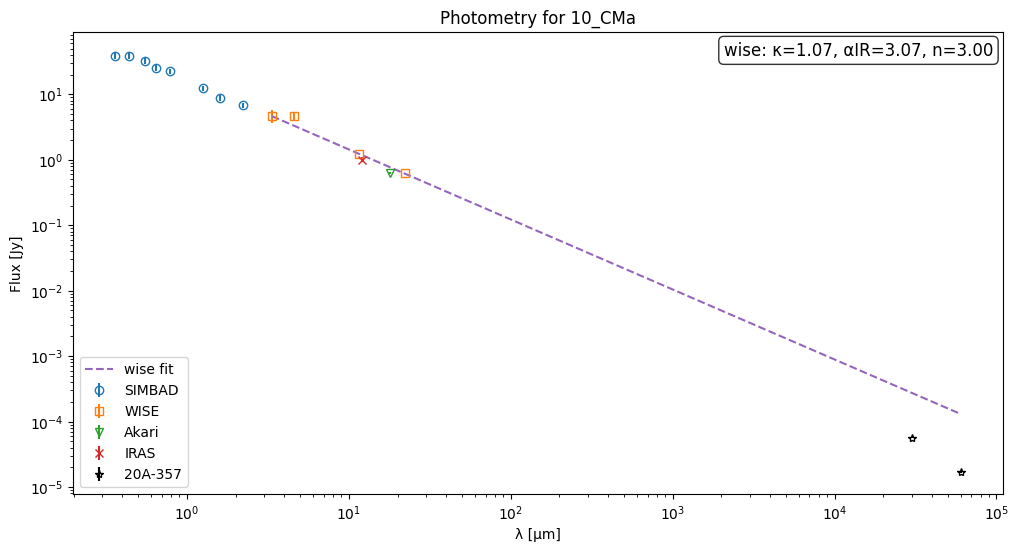

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'iras'. Need at least 2.


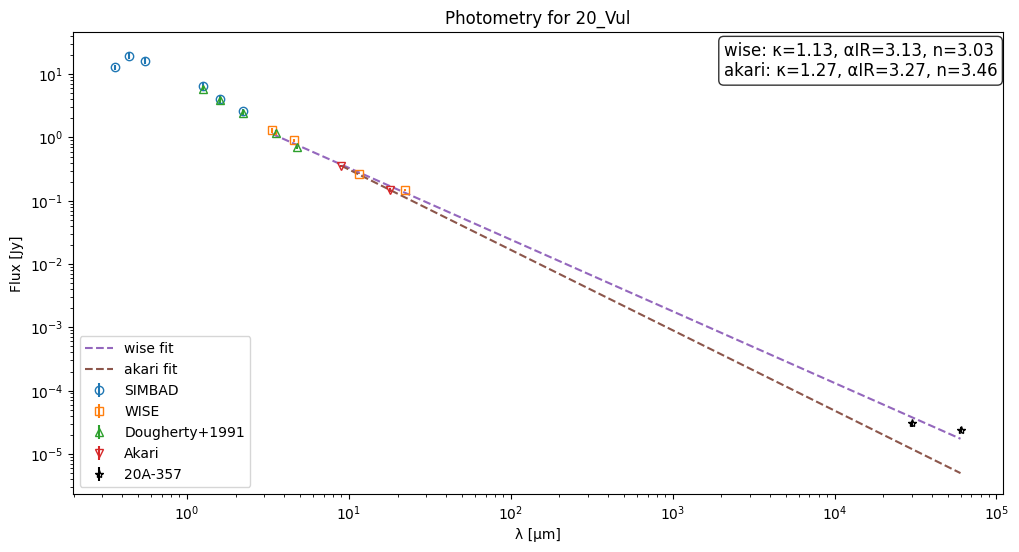

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'iras'. Need at least 2.


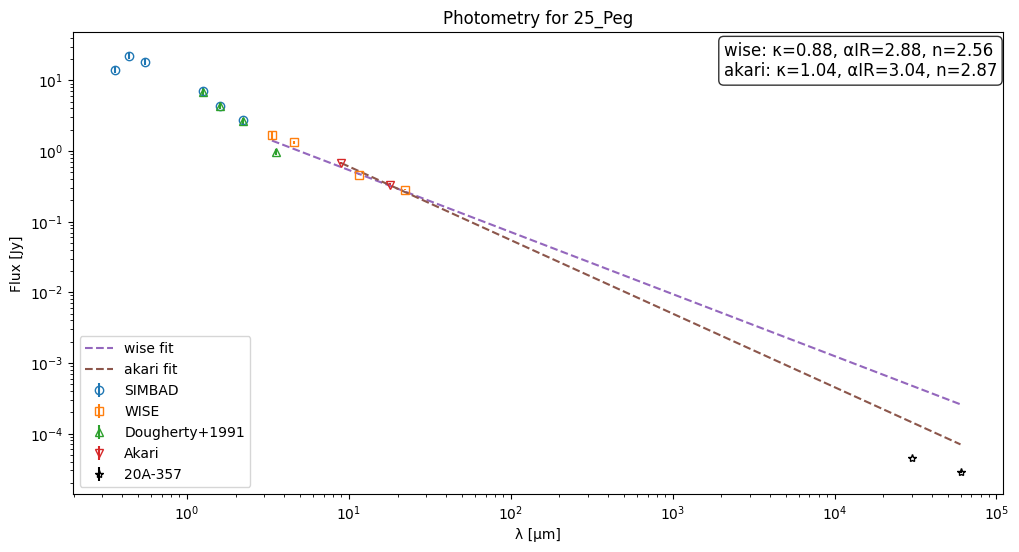

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'iras'. Need at least 2.


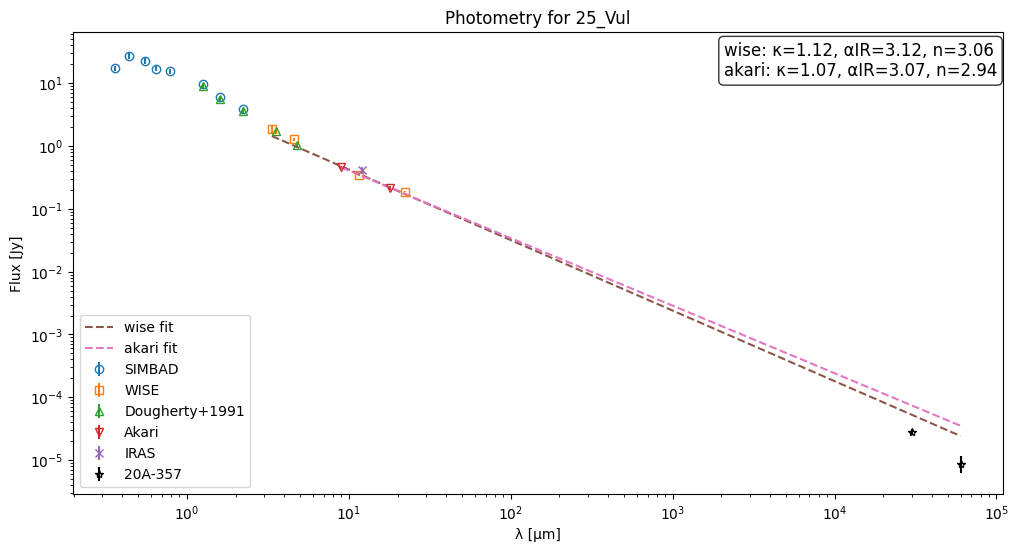

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'iras'. Need at least 2.


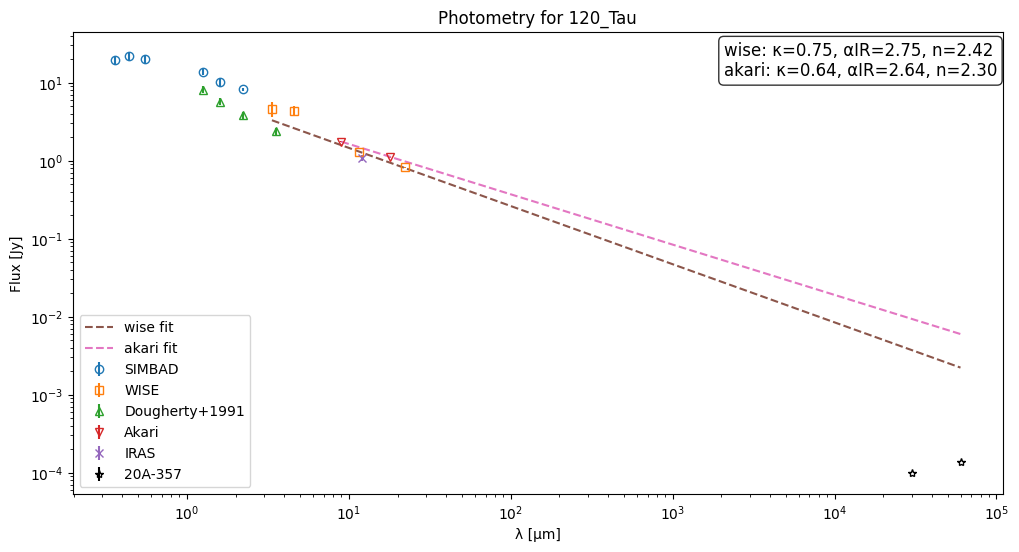

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


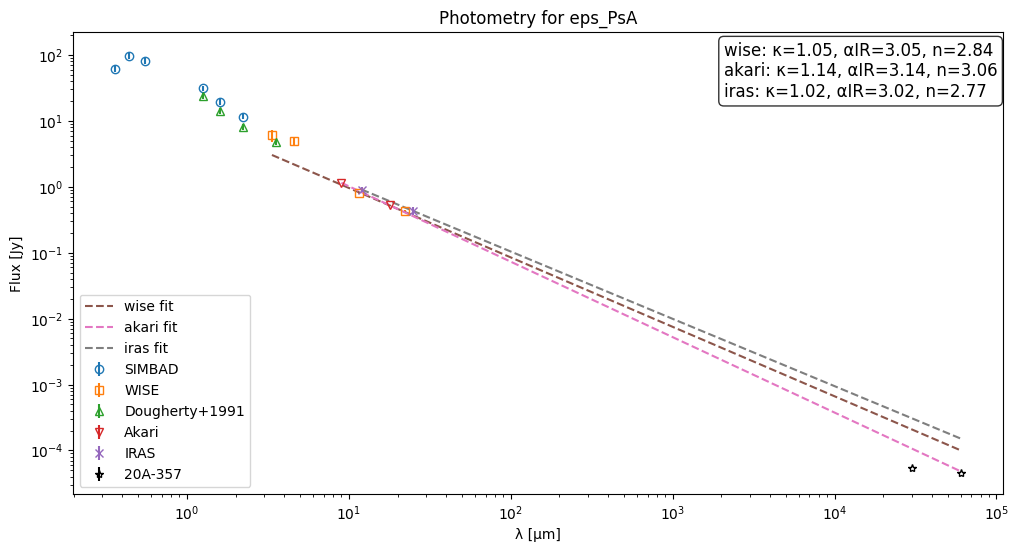

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'akari'. Need at least 2.
Not enough points to fit survey 'iras'. Need at least 2.


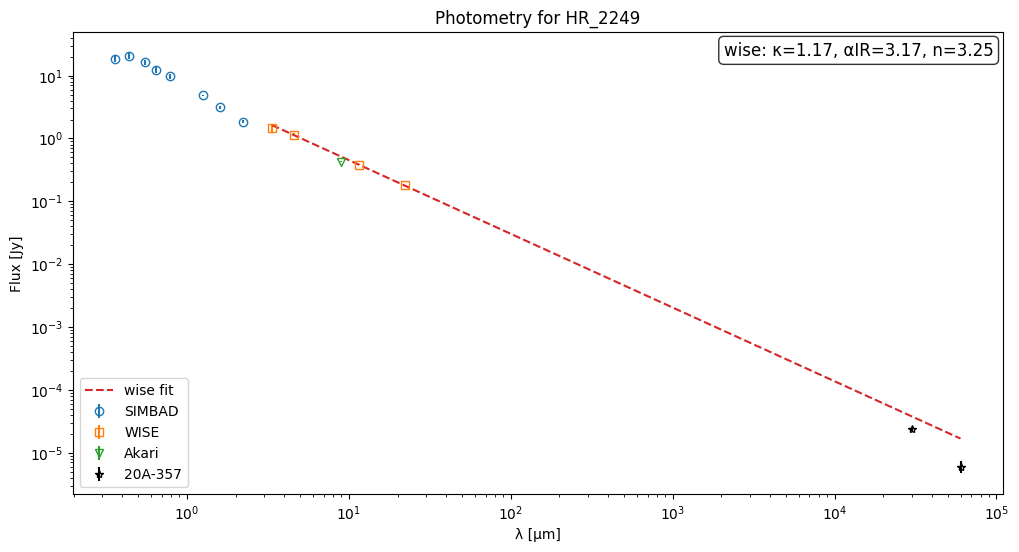

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'wise'. Need at least 2.
Not enough points to fit survey 'iras'. Need at least 2.


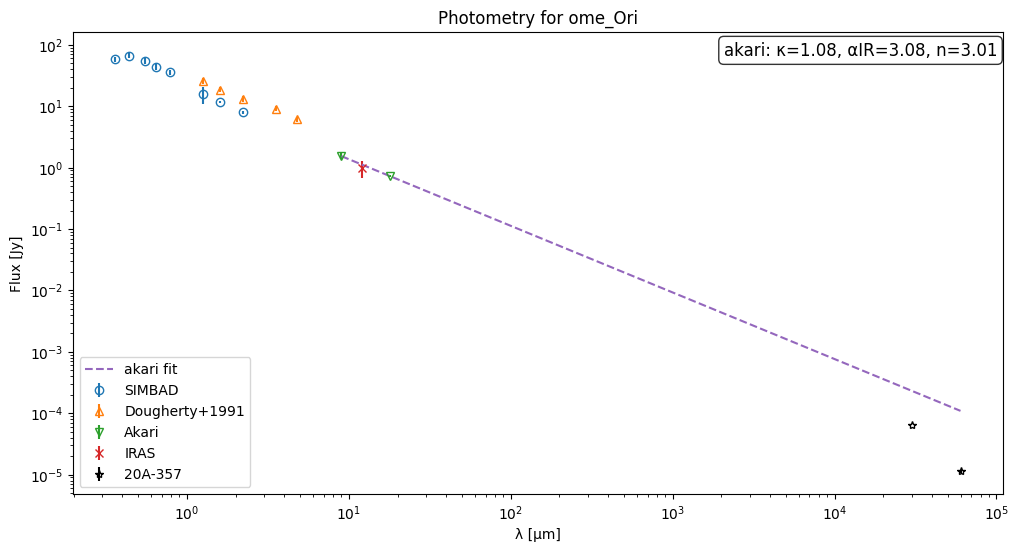

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'iras'. Need at least 2.


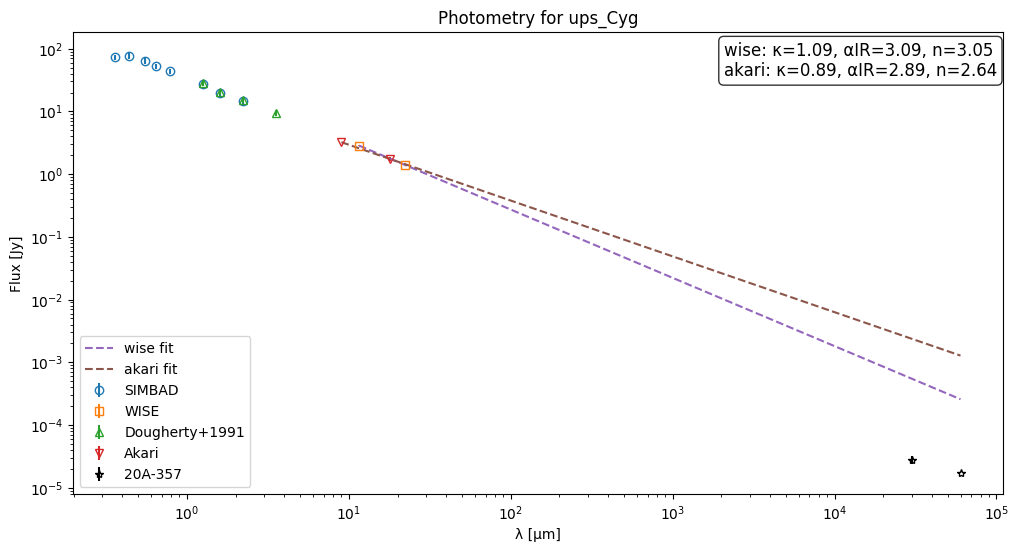

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:116: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  C_table = pd.read_csv(c_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/323528664.py:118: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_table = pd.read_csv(x_path, comment="#", delim_whitespace=True)


Not enough points to fit survey 'akari'. Need at least 2.
Not enough points to fit survey 'iras'. Need at least 2.


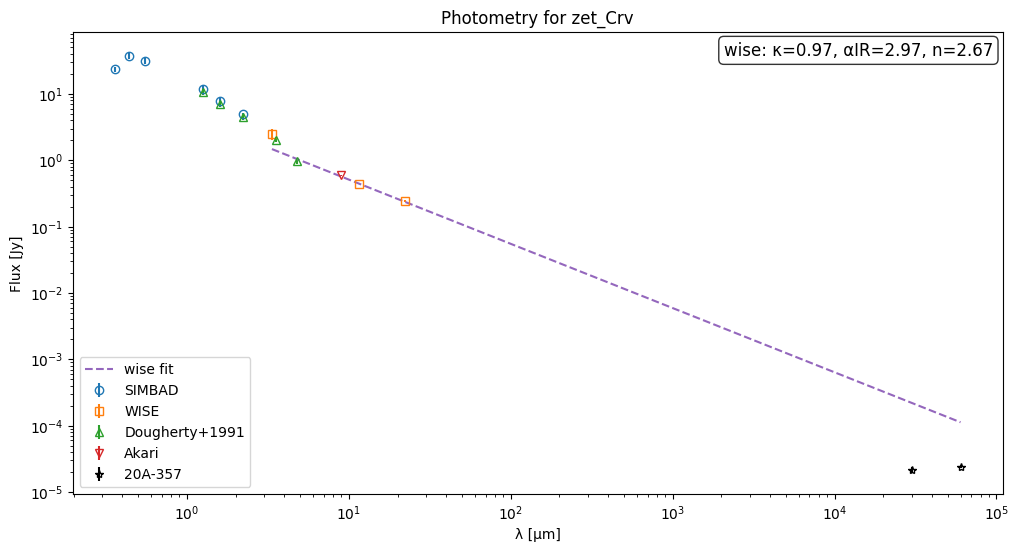

In [57]:
teff_dict = {
    "10_CMa": 25000,    # Frémat et al. 2005
    "20_Vul": 12050,    # direct value
    "25_Peg": 13000,    # literature value for HD 210129 / 25 Peg
    "25_Vul": 13170,    # direct value
    "120_Tau": 24500,   # from log Teff = 4.389
    "eps_PsA": 11066,   # direct value
    "HR_2249": 21500,   # direct value for HD 43544 / HR 2249
    "ome_Ori": 19000,   # direct value
    "ups_Cyg": 22000,   # direct value
    "zet_Crv": 11214,    # direct value
    "HD44637": 18000    # estimate based on spectral type B3III
}

# Need to add errors + erros bars to these

for i in range(len(source_list)):

    result = plot_photometry_with_fit(
        indir=indir,
        outdir=outdir,
        source=source_list[i],
        photometry_name=diff_source_list[i],
        fit_survey=["wise", 'akari', 'iras'],
        fit_in_loglog=True,   # direct F_nu = A * lambda^-kappa fit
        fit_err=False,
        teff=teff_dict.get(source_list[i]),            # needed for n
        annotate_powerlaw=True
    )

# HD44637_indir = os.path.expanduser('~/gdrive/Shared Drives/MACRO-Be/TDEM0040/')

# HD44637_result = plot_photometry_with_fit(
#     indir=HD44637_indir,
#     outdir=outdir,
#     source="HD44637",
#     photometry_name="HD44637",
#     fit_survey=["wise", 'akari', 'iras'],
#     fit_in_loglog=True,   # direct F_nu = A * lambda^-kappa fit
#     fit_err=False,
#     teff=teff_dict.get("HD44637"),            # needed for n
#     annotate_powerlaw=True
# )

    # print(result["fits"])

In [ ]:
# %load_ext autoreload 
# %autoreload 2

/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2837177427.py:145: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2837177427.py:146: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  Ku1_table = pd.read_csv(Ku1_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2837177427.py:147: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  Ku2_table = pd.read_csv(Ku2_path, comment="#", delim_whitespace=True)
/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_76221/2837177427.py:148: FutureWarning: The 'delim_whitespace' key

Not enough points to fit survey 'akari'. Need at least 2.
Not enough points to fit survey 'iras'. Need at least 2.


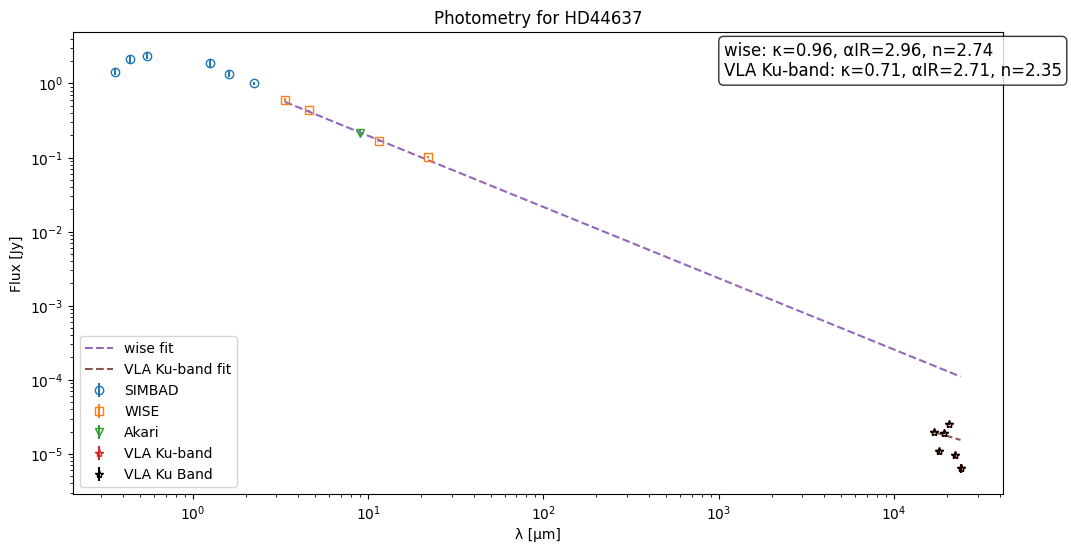

In [ ]:
HD44637_indir = os.path.expanduser('~/gdrive/Shared Drives/MACRO-Be/TDEM0040/')

HD44637_result = plot_photometry_with_fit(
    indir=HD44637_indir,
    outdir=outdir,
    source="HD44637",
    photometry_name="HD44637",
    fit_survey=["wise", 'akari', 'iras', 'VLA Ku-band'],
    fit_in_loglog=True,   # direct F_nu = A * lambda^-kappa fit
    fit_err=False,
    teff=teff_dict.get("HD44637"),            # needed for n
    annotate_powerlaw=True
)